In [1]:
import numpy as np
import reciprocalspaceship as rs
from meteor import rsmap
import logging
import os
logger = logging.getLogger(__name__)
from systematic_plots import (
    load_ocp_paths,
    load_homepath,
    calculate_objects,
    run_plots,
    rescaling_diffmaps,
    find_most_positive_blobs_fixed_basis,
)
%load_ext autoreload
%autoreload 2

In [2]:
dataloc_dark = load_homepath() +"../data/MAXIV_ECH_new/updated/ech-full_dark_dimple.mtz"
dataloc_light = "/Users/sbielfel/Nextcloud2/time_resolved/data/MAXIV_ECH_new/updated/ech-laser_dimple.mtz"
from meteor.utils import cut_resolution

for dloc in [dataloc_dark, dataloc_light]:
    d1 =  rs.read_mtz(dloc)
    d1 = cut_resolution(d1,high_resolution_limit=1.7)
    dmap = rsmap.Map(d1,amplitude_column="F", phase_column="PHIC")
    print(dmap.to_3d_numpy_map(map_sampling=3).shape)


(128, 128, 162)
(128, 128, 162)


In [3]:
dataloc_darks = ["/Users/sbielfel/Nextcloud2/time_resolved/evaluation/OCP/kweighted/OCP_kweighted__best_guess_15.12.mtz"
,"/Users/sbielfel/Nextcloud2/time_resolved/evaluation/OCP/tv/OCP_tv__best_guess_17.48.mtz"]
dataloc_darks = ["/Users/sbielfel/Nextcloud2/time_resolved/evaluation/OCP/kweighted/OCP_kweighted__best_guess_15.09.mtz"
,"/Users/sbielfel/Nextcloud2/time_resolved/evaluation/OCP/tv/OCP_tv__best_guess_18.34.mtz"]
dataloc_darks = ["/Users/sbielfel/Nextcloud2/time_resolved/evaluation/OCP/kweighted/OCP_kweighted__best_guess_15.54.mtz"
,"/Users/sbielfel/Nextcloud2/time_resolved/evaluation/OCP/tv/OCP_tv__best_guess_18.86.mtz"]
dataloc_darks = ["/Users/sbielfel/Nextcloud2/time_resolved/evaluation/OCP/tv/OCP_tv__best_guess_8.22.mtz"]
import pandas as pd
for dataloc_proc in dataloc_darks:
    ds1 = rs.read_mtz(dataloc_proc)
    ds_dark = rs.read_mtz(dataloc_light)
    ds_dark["F"] = ds1["F"]
    mask = pd.isna(ds_dark["F"])
    ds_dark.loc[mask,"SIGF"] = np.nan
    # ds_dark.loc[mask,"FC"] = np.nan
    ds_dark["PHIC"] = ds1["PHI"]
    write_path = dataloc_proc.replace(".mtz", "_full_res.mtz")
    ds_dark.write_mtz(write_path)
    tup = (1,1,1)
    # idx = pd.IndexSlice.from_tuples([tup], names=ds_dark.index.names)
    # ds_dark.loc[pd.IndexSlice[13,3,-21]]) = np.nan

    print(ds_dark.loc[pd.IndexSlice[13,3,-21]])


FreeR_flag              4
F                32.64563
SIGF                 <NA>
FC              96.405197
PHIC           -172.80275
FC_ALL         113.003197
PHIC_ALL       164.841324
FWT            113.003197
PHWT           164.841324
DELFWT                0.0
PHDELWT               0.0
FOM                   0.0
FC_ALL_LS      111.914474
PHIC_ALL_LS    165.340851
Name: (13, 3, -21), dtype: object


In [4]:
ds1 = rs.read_mtz(dataloc_proc)
ds_dark = rs.read_mtz(dataloc_dark)
ds_dark["F"] = ds1["F"]
mask = pd.isna(ds_dark["F"])
ds_dark.loc[mask,"SIGF"] = np.nan
# ds_dark.loc[mask,"FC"] = np.nan
ds_dark["PHIC"] = ds1["PHI"]
write_path = dataloc_proc.replace(".mtz", "_dimple.mtz")
ds_dark.write_mtz(write_path)
tup = (1,1,1)
# idx = pd.IndexSlice.from_tuples([tup], names=ds_dark.index.names)
# ds_dark.loc[pd.IndexSlice[13,3,-21]] = np.nan

print(ds_dark.loc[pd.IndexSlice[13,3,-21]])


FreeR_flag              4
F                32.64563
SIGF             6.401481
FC              90.125679
PHIC           -172.80275
FC_ALL         109.242371
PHIC_ALL        165.43898
FWT             70.149734
PHWT           345.438995
DELFWT         179.392105
PHDELWT        345.438995
FOM              0.549683
FC_ALL_LS      106.165886
PHIC_ALL_LS    165.449036
Name: (13, 3, -21), dtype: object


In [5]:
fofo_path = load_homepath() +"../data/MAXIV_ECH_new/updated/MAXIV_ECH_newmask_FoFoPHFc.mtz"
rs.read_mtz(fofo_path)


FoFo   PHFc
H  K L                   
0  0 6   77.250961  180.0
     9   19.859903  180.0
     12  28.893751    0.0
     15  12.657664  180.0
     18  52.534416    0.0
...            ...    ...
43 0 3    1.184161    0.0
     4    3.507611  120.0
     5    0.359981   60.0
     6    8.019916 -180.0
     7    4.066943  120.0

[42694 rows x 2 columns]

2025-08-24 18:03:27,074: systematic_plots: INFO: Reading from /Users/sbielfel/Nextcloud2/time_resolved/occupancy-estimation/../evaluation/OCP/diffmaps17.mtz (systematic_plots.py:1627)
2025-08-24 18:03:27,085: __main__: INFO: diffmap_path: /Users/sbielfel/Nextcloud2/time_resolved/occupancy-estimation/../evaluation/OCP/FoFo/ (3882760040.py:60)
2025-08-24 18:03:27,086: systematic_plots: INFO: Created extrapolation factors ranging from 1 to 30 with mid at 11 (systematic_plots.py:1892)
2025-08-24 18:03:27,086: systematic_plots: INFO: Setting thresholds from 0.55 to 1 with step 0.05 (systematic_plots.py:1876)
2025-08-24 18:03:27,139: systematic_plots: ERROR: Diffmap 3*sig: 0.03, max negative: -0.08 (systematic_plots.py:1909)
2025-08-24 18:03:27,450: systematic_plots: INFO: Function selection provided: ['many_negsum_many_thresh'] (systematic_plots.py:2006)
2025-08-24 18:03:27,450: systematic_plots: INFO: Running Many NegSum - Best Guess (systematic_plots.py:1748)
2025-08-24 18:03:27,549: mete

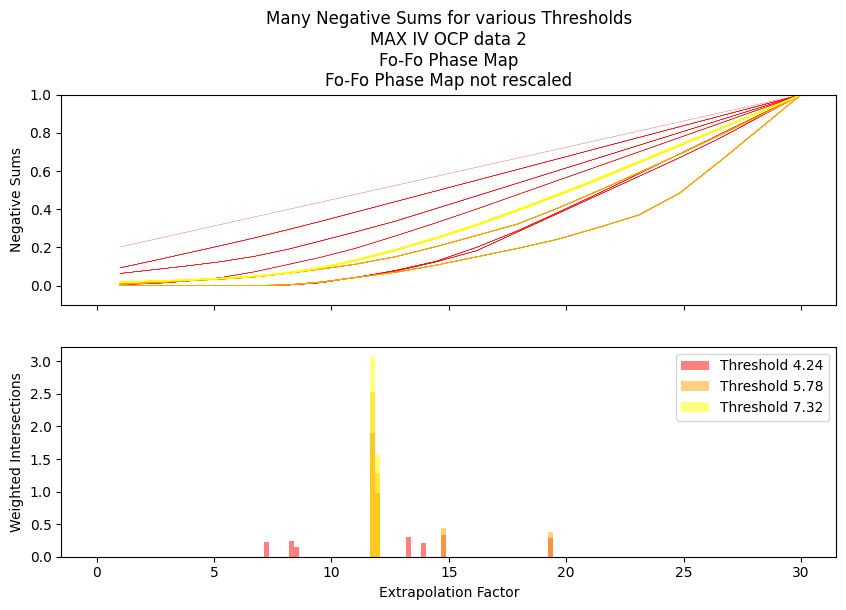

2025-08-24 18:03:38,034: meteorize: WARNING: Intersection at -4.77 should be between 5.29 and 23.09 (meteorize.py:175)
2025-08-24 18:03:38,035: meteorize: WARNING:     Intersection declared invalid (meteorize.py:184)


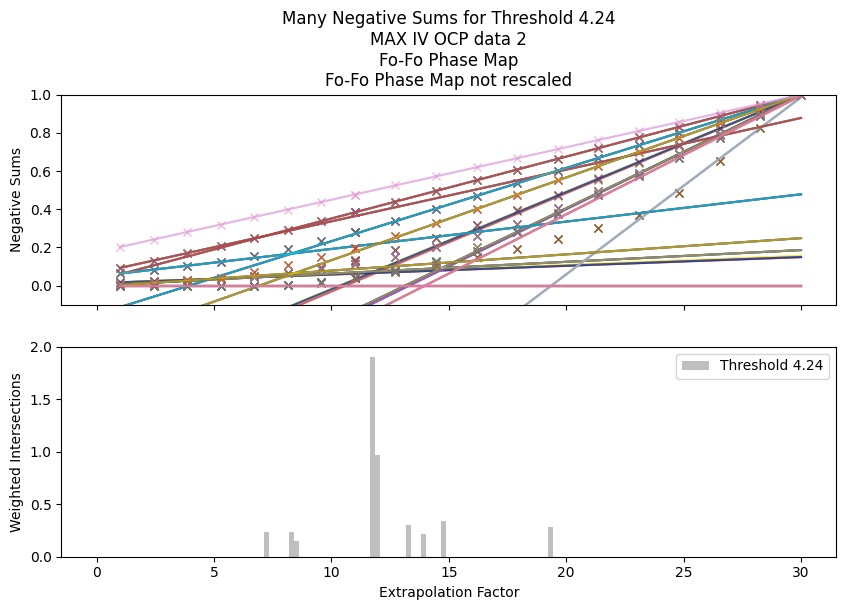

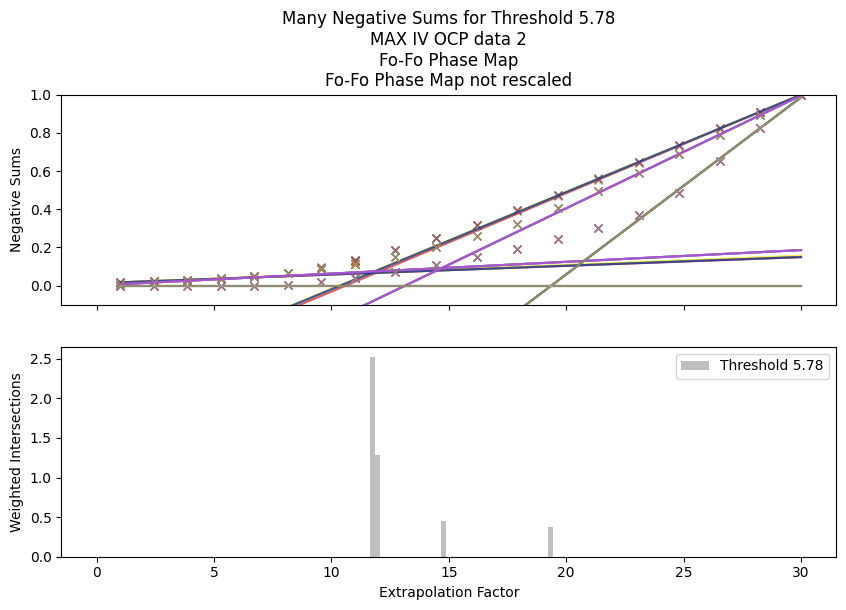

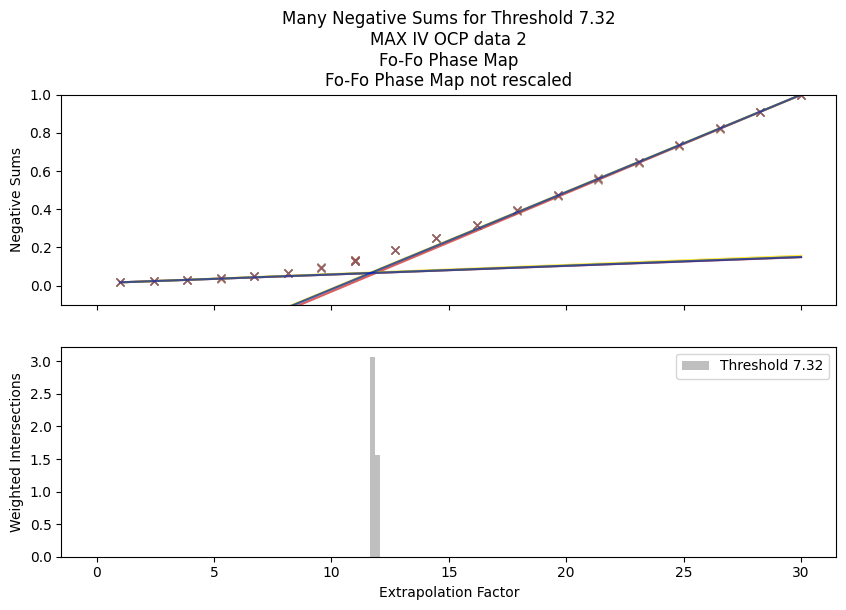

2025-08-24 18:03:38,747: systematic_plots: INFO: Nothing to compare and not even the desire to do so (systematic_plots.py:2040)
2025-08-24 18:03:38,749: systematic_plots: INFO: Created extrapolation factors ranging from 1 to 30 with mid at 11 (systematic_plots.py:1892)
2025-08-24 18:03:38,750: systematic_plots: INFO: Setting thresholds from 0.55 to 1 with step 0.05 (systematic_plots.py:1876)
2025-08-24 18:03:38,804: systematic_plots: ERROR: Diffmap 3*sig: 0.03, max negative: -0.08 (systematic_plots.py:1909)
2025-08-24 18:03:39,110: systematic_plots: INFO: Function selection provided: ['many_negsum_many_thresh'] (systematic_plots.py:2006)
2025-08-24 18:03:39,110: systematic_plots: INFO: Running Many NegSum - Best Guess (systematic_plots.py:1748)
2025-08-24 18:03:39,230: meteorize: WARNING: Used threshold for posmask: 0.584, found 51 blobs (meteorize.py:580)
2025-08-24 18:03:39,300: systematic_plots: INFO: Calculating many negsum for threshold 4.24 (systematic_plots.py:294)
2025-08-24 18

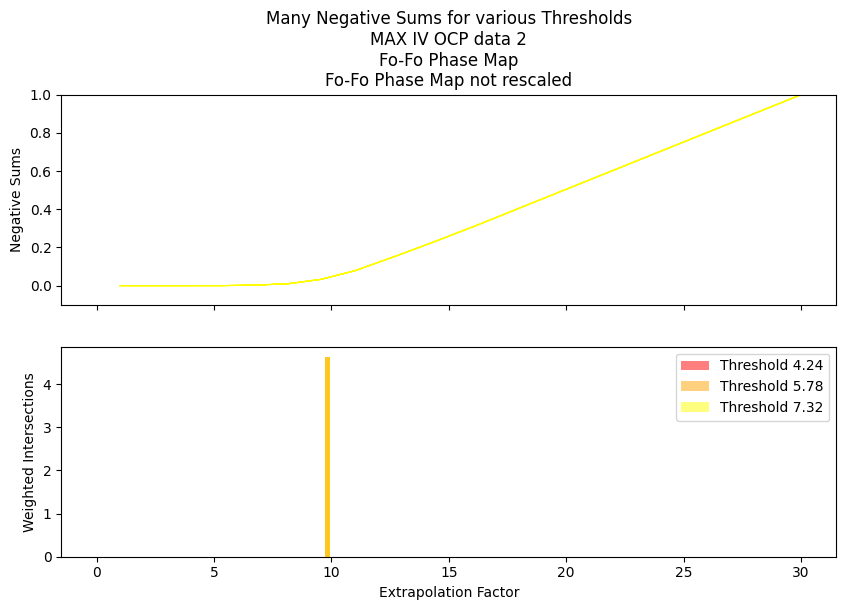

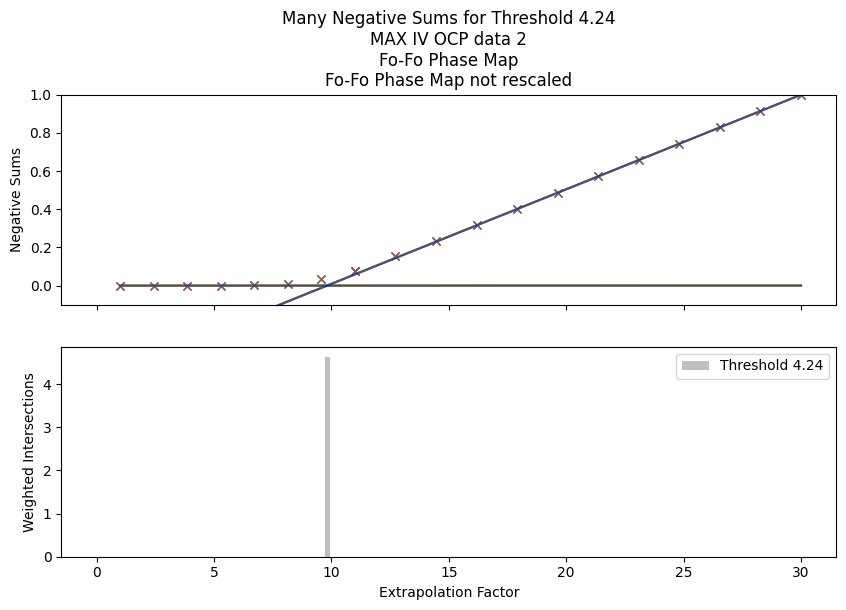

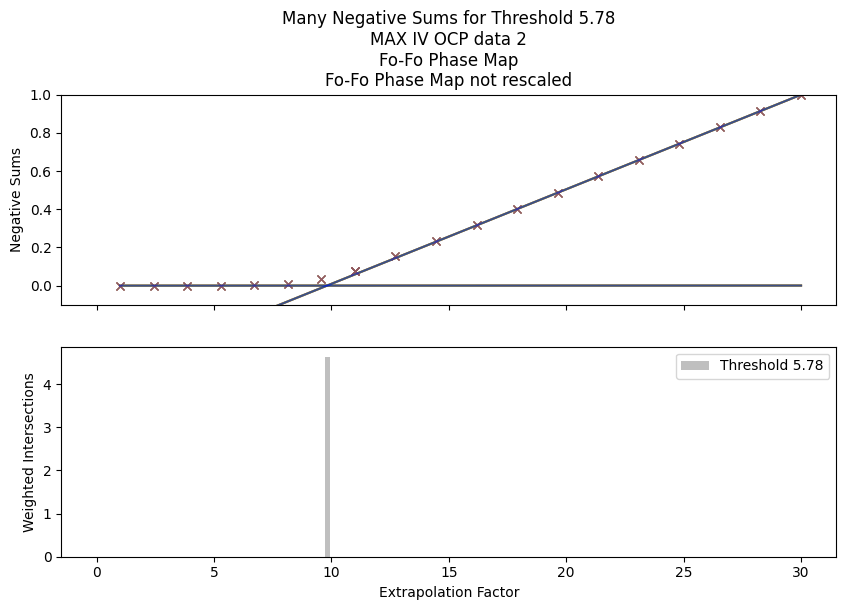

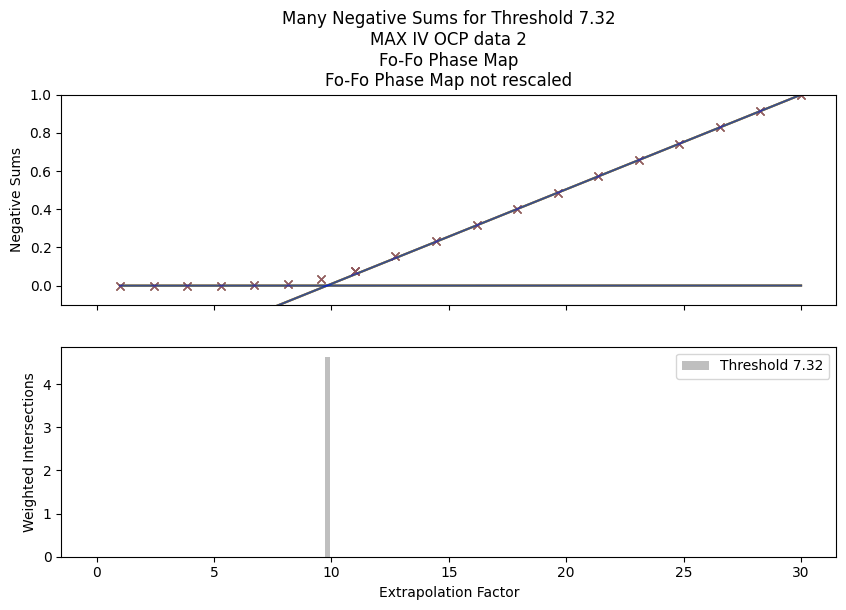

2025-08-24 18:03:43,834: systematic_plots: INFO: Nothing to compare and not even the desire to do so (systematic_plots.py:2040)


In [35]:

# pdbloc_light, map_xtrs = load_photolyase_paths()
filename_dict = {
    "save_fig": False,
    "display": True,
    "rerun": True,
    "rerun_old_only": False,
    "rescaling_diffmaps": False,
}
if filename_dict.get("rescaling_diffmaps", False):
    xtr_settings = {
        "mid_xtr_factor": 3.5,
        "max_xtr_factor": 60,
    }
else:
    xtr_settings = {
        "mid_xtr_factor": 11,
        "max_xtr_factor": 30,
    }
if False:
    extra_info = {
        "minimum_threshold": 4,
        "maximum_threshold": 14,
    } | xtr_settings
extra_info = {
    "minimum_threshold": 0.55,
    "save_extrapolated": True,
} | xtr_settings
function_selection = [
    # "single_negsum_overview",
    # "many_negsum_best_guess",
    "many_negsum_many_thresh",
    # "show_comparison",
]
blob_selection_func = find_most_positive_blobs_fixed_basis
info_container = load_ocp_paths()[0]
evaluation_path = load_homepath() + "../evaluation/"
if not os.path.exists(evaluation_path):
    os.makedirs(evaluation_path)

fofo_path = load_homepath() +"../data/MAXIV_ECH_new/updated/MAXIV_ECH_newmask_FoFoPHFc.mtz"

fofo_path = load_homepath() +"../data/MAXIV_ECH_new/updated/MAXIV_ECH_newmask_FoFoPHFc.mtz"
ds_diff = rs.read_mtz(fofo_path)
from systematic_plots import cut_resolution
hs_limit = info_container["hs_limit"] 
ds_diff = cut_resolution(ds_diff, high_resolution_limit=hs_limit)
diffmap = rsmap.Map(ds_diff, amplitude_column="FoFo", phase_column="PHFc")

diffmaps2, map_dark, info_container, evaluation_path_basis = calculate_objects(
    info_container, evaluation_path
)
info_container = info_container | extra_info

diffmap_id = "FoFo"
info_container["diffmap_config"] = {}
info_container["diffmap_config"][diffmap_id] = {"title": "Fo-Fo Phase Map"}
diffmap_path = evaluation_path_basis + f"{diffmap_id}/"
filestart = f"{info_container['fshort']}_{diffmap_id}_"
os.makedirs(diffmap_path, exist_ok=True)
logger.info(f"diffmap_path: {diffmap_path}")
filename_dict2 = {
    "diffmap_path": diffmap_path,
    "filestart": filestart,
} | filename_dict

for sigma in [3., 4.5]:
    info_container["sigma"] = sigma
    run_plots(
        diffmap,
        map_dark,
        info_container,
    diffmap_id,
    filename_dict2,
    function_selection=function_selection,
    blob_selection_func=blob_selection_func,
)


In [ ]:
info_container["sigma"] = 2.5
info_container["minimum_threshold"]= 0.3

run_plot(
    diffmap,
    map_dark,
    info_container,
    diffmap_id,
    filename_dict2,
    function_selection=function_selection,
    blob_selection_func=blob_selection_func,
)



2025-08-23 17:40:14,418: systematic_plots: INFO: Created extrapolation factors ranging from 1 to 180 with mid at 6 (systematic_plots.py:1885)
2025-08-23 17:40:14,418: systematic_plots: INFO: Setting thresholds from 0.3 to 1 with step 0.05 (systematic_plots.py:1869)
2025-08-23 17:40:14,670: systematic_plots: ERROR: Diffmap 3*sig: 0.03, max negative: -0.08 (<string>:9)
2025-08-23 17:40:14,671: systematic_plots: INFO: Function selection provided: ['many_negsum_best_guess'] (<string>:44)
2025-08-23 17:40:14,671: systematic_plots: INFO: Running Many NegSum - Best Guess (<string>:2)
2025-08-23 17:40:14,729: meteorize: WARNING: Used threshold for posmask: 0.325, found 4104 blobs (meteorize.py:580)


TypeError: filter_pos_blobs_rmsd() got an unexpected keyword argument 'threshold'

In [28]:
filename_dict = {
    "save_fig": False,
    "display": False,
    "rerun": True,
    "rerun_old_only": False,
    "rescaling_diffmaps": False,
}
function_selection = [
    # "single_negsum_overview",
    "many_negsum_best_guess",
    # "many_negsum_many_thresh",
    # "show_comparison",
]


sigmas = np.arange(2.5, 6.7, 0.5)
outputs = []
for sigma in sigmas:
    info_container["sigma"] = sigma
    logger.warning(f"Setting sigma to {sigma}")
    filename_dict2 = {
        "diffmap_path": diffmap_path,
        "filestart": filestart + f"s{sigma}_",
    } | filename_dict
    output = run_plots(
        diffmap,
        map_dark,
        info_container,
        diffmap_id,
        filename_dict2,
        function_selection=function_selection,
        blob_selection_func=blob_selection_func,
    )
    outputs.append((info_container, output))

2025-08-24 17:33:11,771: __main__: WARNING: Setting sigma to 2.5 (3327309696.py:20)
2025-08-24 17:33:11,772: systematic_plots: INFO: Created extrapolation factors ranging from 1 to 40 with mid at 6 (systematic_plots.py:1892)
2025-08-24 17:33:11,772: systematic_plots: INFO: Setting thresholds from 0.75 to 1 with step 0.05 (systematic_plots.py:1876)
2025-08-24 17:33:11,826: systematic_plots: ERROR: Diffmap 3*sig: 0.03, max negative: -0.08 (systematic_plots.py:1909)
2025-08-24 17:33:12,137: systematic_plots: INFO: Function selection provided: ['many_negsum_best_guess'] (systematic_plots.py:2006)
2025-08-24 17:33:12,138: systematic_plots: INFO: Running many_negsum_best_guess (systematic_plots.py:1669)
2025-08-24 17:33:12,138: systematic_plots: INFO: Running Many NegSum - Best Guess (systematic_plots.py:1709)
2025-08-24 17:33:12,223: meteorize: WARNING: Used threshold for posmask: 0.325, found 4104 blobs (meteorize.py:580)
2025-08-24 17:33:18,981: meteorize: INFO: Intersection Average: 13.1

Beware of your choice


2025-08-24 17:33:25,393: meteorize: INFO: Intersection Average: 12.96 ± 2.64Inverse: 0.08 ± 0.01 (meteorize.py:278)
2025-08-24 17:33:25,407: meteorize: INFO: Total mask sum: 1356, Total weight sum: 53.508420050144196 (meteorize.py:284)
2025-08-24 17:33:25,408: meteorize: WARNING: Many NaN values in intersection points (weighted) 0.00 out of 1 (meteorize.py:297)


Beware of your choice


2025-08-24 17:33:32,022: meteorize: INFO: Intersection Average: 12.22 ± 0.00Inverse: 0.08 ± 0.00 (meteorize.py:278)
2025-08-24 17:33:32,030: meteorize: INFO: Total mask sum: 1248, Total weight sum: 49.06556224822998 (meteorize.py:284)
2025-08-24 17:33:32,030: meteorize: WARNING: Many NaN values in intersection points (weighted) 0.00 out of 1 (meteorize.py:297)


...

Beware of your choice


2025-08-24 17:34:47,582: meteorize: INFO: Intersection Average: 9.08 ± 0.00Inverse: 0.11 ± 0.00 (meteorize.py:278)
2025-08-24 17:34:47,597: meteorize: INFO: Total mask sum: 66, Total weight sum: 4.632047772407532 (meteorize.py:284)
2025-08-24 17:34:47,599: meteorize: WARNING: Many NaN values in intersection points (weighted) 0.00 out of 1 (meteorize.py:297)
2025-08-24 17:34:47,672: root: INFO: Violin Width: 0.1926 (systematic_plots.py:519)
2025-08-24 17:34:47,769: __main__: WARNING: Setting sigma to 6.5 (3327309696.py:20)
2025-08-24 17:34:47,770: systematic_plots: INFO: Created extrapolation factors ranging from 1 to 40 with mid at 6 (systematic_plots.py:1892)
2025-08-24 17:34:47,770: systematic_plots: INFO: Setting thresholds from 0.75 to 1 with step 0.05 (systematic_plots.py:1876)


Beware of your choice


2025-08-24 17:34:47,829: systematic_plots: ERROR: Diffmap 3*sig: 0.03, max negative: -0.08 (systematic_plots.py:1909)
2025-08-24 17:34:48,166: systematic_plots: INFO: Function selection provided: ['many_negsum_best_guess'] (systematic_plots.py:2006)
2025-08-24 17:34:48,167: systematic_plots: INFO: Running many_negsum_best_guess (systematic_plots.py:1669)
2025-08-24 17:34:48,167: systematic_plots: INFO: Running Many NegSum - Best Guess (systematic_plots.py:1709)
2025-08-24 17:34:48,296: meteorize: WARNING: Used threshold for posmask: 0.844, found 6 blobs (meteorize.py:580)
2025-08-24 17:34:48,327: meteorize: ERROR: Error: No masks provided, masks has 0  . (meteorize.py:212)
2025-08-24 17:34:48,327: systematic_plots: WARNING: Not enough masks found for threshold 5.78 (systematic_plots.py:245)


UnboundLocalError: cannot access local variable 'intersection_points' where it is not associated with a value

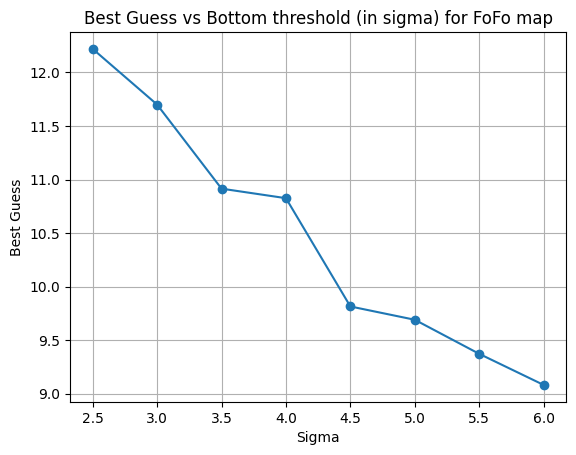

In [ ]:
import matplotlib.pyplot as plt
last_guess = [out[1]["many_negsum_best_guess"]["best_guess"][-1] for out in outputs]
plt.figure()
plt.plot(sigmas[:-1], last_guess, marker='o')
plt.xlabel("Sigma")
plt.ylabel("Determined extrapolation Factor of 'strongest' peak")
plt.title(f"Extrapolation Factor vs Bottom threshold (in sigma) for FoFo map")
plt.grid()
# plt.savefig(f"{diffmap_path}{filestart}_best_guess_vs_sigma.png")
plt.show()


In [ ]:
print( diffmap.to_3d_numpy_map(map_sampling=2.8).shape)
print(diffmaps2["tv"].to_3d_numpy_map(map_sampling=3).shape)
print(map_dark.to_3d_numpy_map(map_sampling=3).shape)
print(diffmap.cell)
print(map_dark.cell)
print(map_dark.spacegroup)
print(diffmap.spacegroup)



(128, 128, 162)
(128, 128, 150)
(128, 128, 150)
<gemmi.UnitCell(83.15, 83.15, 89.48, 90, 90, 120)>
<gemmi.UnitCell(83.15, 83.15, 89.48, 90, 90, 120)>
<gemmi.SpaceGroup("P 32 2 1")>
<gemmi.SpaceGroup("P 32 2 1")>


array([[ 0,  0,  6],
       [ 0,  0,  9],
       [ 0,  0, 12],
       ...,
       [43,  0,  5],
       [43,  0,  6],
       [43,  0,  7]], dtype=int32)

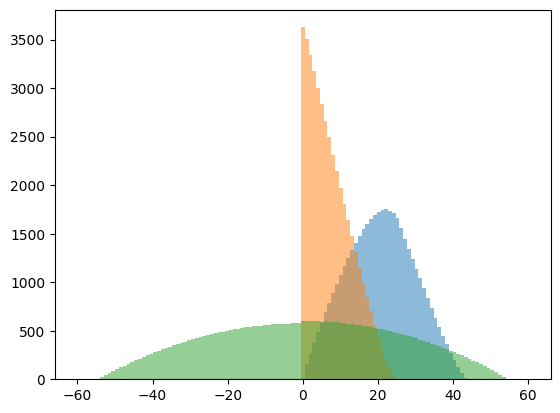

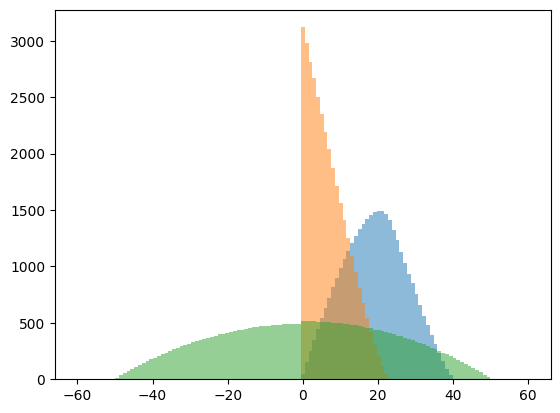

[40 23 49]
[43 25 53]


In [ ]:
import matplotlib.pyplot as plt
plt.figure()
bins = np.linspace(-60, 60, 120)
plt.hist(diffmap.get_hkls()[:,0], bins = bins, alpha=0.5, label='h')
plt.hist(diffmap.get_hkls()[:,1], bins = bins, alpha=0.5, label='k')
plt.hist(diffmap.get_hkls()[:,2], bins = bins, alpha=0.5, label='l')
plt.show()
plt.figure()
plt.hist(diffmaps2["tv"].get_hkls()[:,0], bins = bins, alpha=0.5, label='h')
plt.hist(diffmaps2["tv"].get_hkls()[:,1], bins = bins, alpha=0.5, label='k')
plt.hist(diffmaps2["tv"].get_hkls()[:,2], bins = bins, alpha=0.5, label='l')
plt.show()
print(np.max(diffmaps2["tv"].get_hkls(), axis=0))
print(np.max(diffmap.get_hkls(), axis=0))

2025-08-23 17:54:03,798: systematic_plots: INFO: Created extrapolation factors ranging from 1 to 180 with mid at 6 (systematic_plots.py:1885)
2025-08-23 17:54:03,799: systematic_plots: INFO: Setting thresholds from 0.3 to 1 with step 0.05 (systematic_plots.py:1869)
2025-08-23 17:54:04,054: systematic_plots: ERROR: Diffmap 3*sig: 0.03, max negative: -0.08 (<string>:9)
2025-08-23 17:54:04,055: systematic_plots: INFO: Function selection provided: ['many_negsum_best_guess'] (<string>:44)
2025-08-23 17:54:04,055: systematic_plots: INFO: Running Many NegSum - Best Guess (<string>:2)
2025-08-23 17:54:04,112: meteorize: WARNING: Used threshold for posmask: 0.325, found 4104 blobs (meteorize.py:580)
2025-08-23 17:54:12,600: meteorize: WARNING: Fits are parallel (would have been 40.06, 0.0, 1.0, 0.0,  1.0 ) (meteorize.py:257)
2025-08-23 17:54:12,601: meteorize: WARNING: Fits are parallel (would have been 56.65, 0.0, 1.0, 0.0,  1.0 ) (meteorize.py:257)
2025-08-23 17:54:12,601: meteorize: WARNING:

Beware of your choice


2025-08-23 17:54:13,066: meteorize: INFO: Total mask sum: 5438, Total weight sum: 185.02904796600342 (meteorize.py:284)
2025-08-23 17:54:13,067: meteorize: ERROR: Many NaN values in intersection points 0.34 , consider adjusting your analysis. (meteorize.py:295)
2025-08-23 17:54:13,067: meteorize: WARNING: Many NaN values in intersection points (weighted) 0.23 out of 1 (meteorize.py:297)
2025-08-23 17:54:22,103: meteorize: WARNING: Fits are parallel (would have been 40.06, 0.0, 1.0, 0.0,  1.0 ) (meteorize.py:257)
2025-08-23 17:54:22,104: meteorize: WARNING: Fits are parallel (would have been 56.65, 0.0, 1.0, 0.0,  1.0 ) (meteorize.py:257)
2025-08-23 17:54:22,104: meteorize: WARNING: Fits are parallel (would have been 56.06, 0.0, 1.0, 0.0,  1.0 ) (meteorize.py:257)
2025-08-23 17:54:22,105: meteorize: WARNING: Fits are parallel (would have been 72.25, 0.0, 1.0, 0.0,  1.0 ) (meteorize.py:257)
2025-08-23 17:54:22,105: meteorize: WARNING: Intersection at -1511.06 should be between 3.14 and 1

Beware of your choice


2025-08-23 17:54:22,615: meteorize: INFO: Total mask sum: 5438, Total weight sum: 185.02904796600342 (meteorize.py:284)
2025-08-23 17:54:22,615: meteorize: ERROR: Many NaN values in intersection points 0.34 , consider adjusting your analysis. (meteorize.py:295)
2025-08-23 17:54:22,615: meteorize: WARNING: Many NaN values in intersection points (weighted) 0.23 out of 1 (meteorize.py:297)
2025-08-23 17:54:31,710: meteorize: WARNING: Fits are parallel (would have been 56.65, 0.0, 1.0, 0.0,  1.0 ) (meteorize.py:257)
2025-08-23 17:54:31,710: meteorize: WARNING: Fits are parallel (would have been 40.06, 0.0, 1.0, 0.0,  1.0 ) (meteorize.py:257)
2025-08-23 17:54:31,711: meteorize: WARNING: Fits are parallel (would have been 5.69, 0.0, 0.9, 0.0,  1.0 ) (meteorize.py:257)
2025-08-23 17:54:31,711: meteorize: WARNING: Fits are parallel (would have been 72.25, 0.0, 1.0, 0.0,  1.0 ) (meteorize.py:257)
2025-08-23 17:54:31,712: meteorize: WARNING: Intersection at -1511.06 should be between 3.14 and 11

...

Beware of your choice


2025-08-23 17:55:23,595: meteorize: INFO: Intersection Average: 12.25 ± 0.00Inverse: 0.08 ± 0.00 (meteorize.py:278)
2025-08-23 17:55:23,599: meteorize: INFO: Total mask sum: 1248, Total weight sum: 49.06556224822998 (meteorize.py:284)
2025-08-23 17:55:23,599: meteorize: WARNING: Many NaN values in intersection points (weighted) 0.00 out of 1 (meteorize.py:297)


Beware of your choice


2025-08-23 17:55:28,064: meteorize: INFO: Intersection Average: 12.25 ± 0.00Inverse: 0.08 ± 0.00 (meteorize.py:278)
2025-08-23 17:55:28,068: meteorize: INFO: Total mask sum: 1248, Total weight sum: 49.06556224822998 (meteorize.py:284)
2025-08-23 17:55:28,068: meteorize: WARNING: Many NaN values in intersection points (weighted) 0.00 out of 1 (meteorize.py:297)
2025-08-23 17:55:28,077: root: INFO: Violin Width: 0.1926 (<string>:14)


Beware of your choice


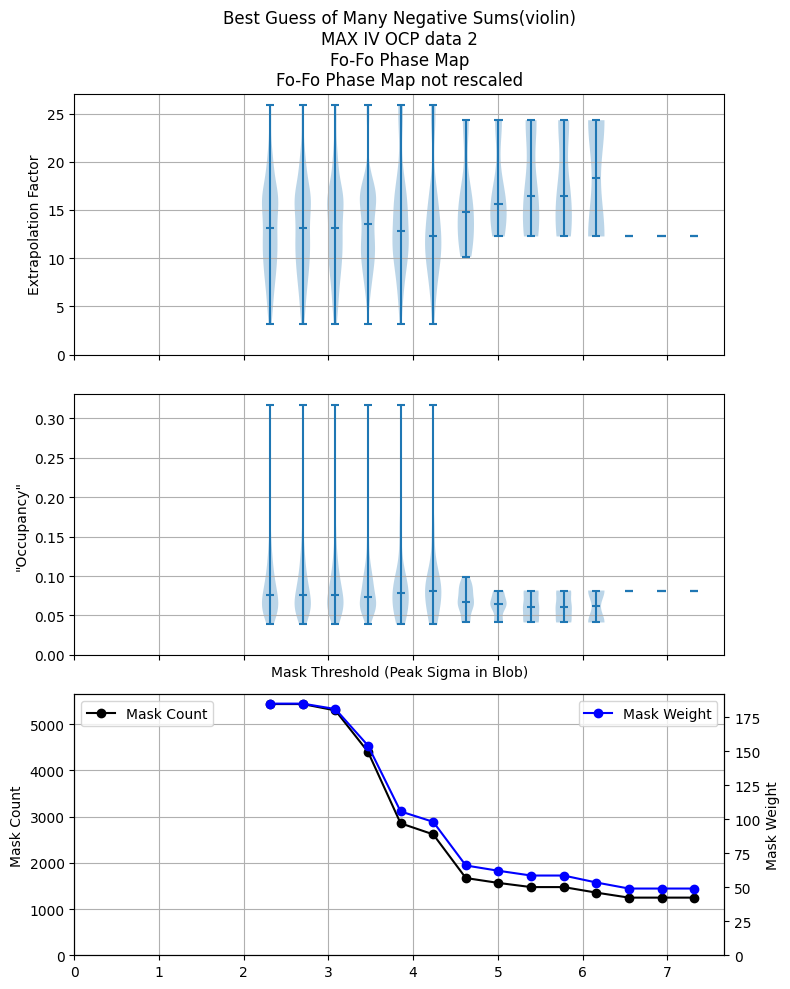

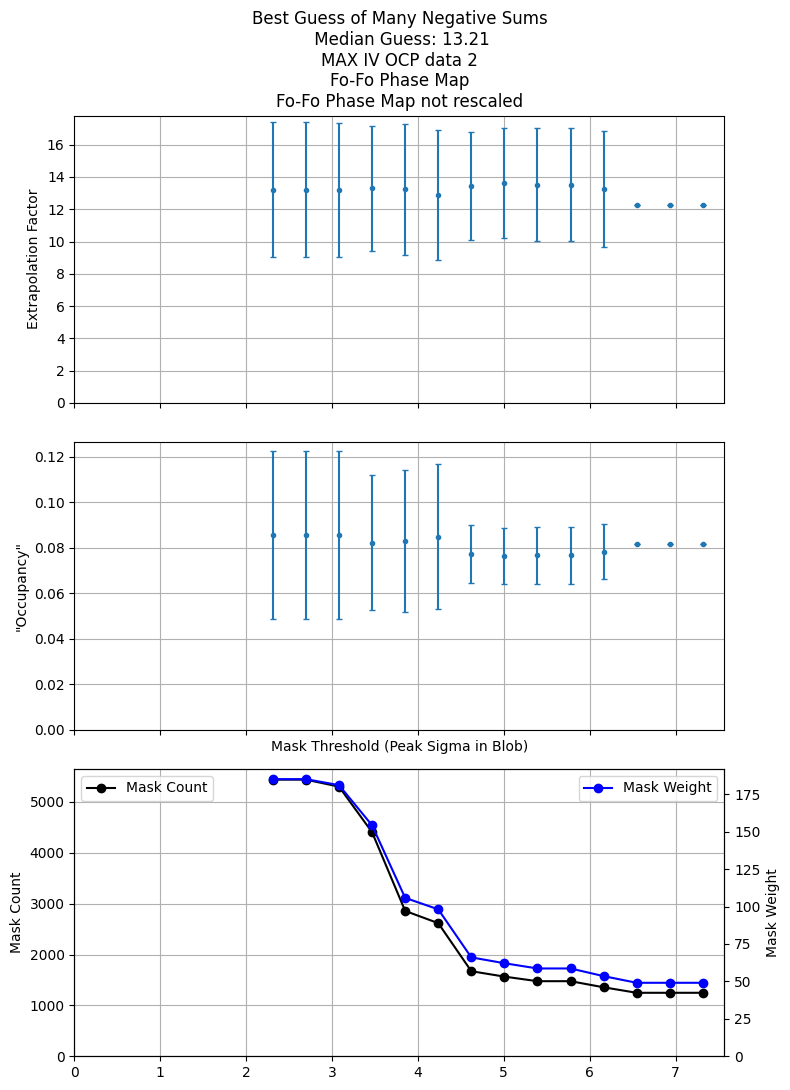

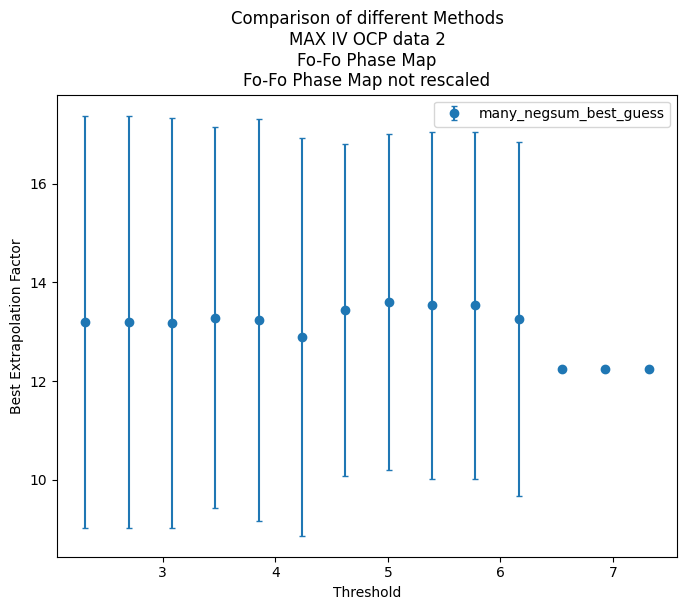

{'extrapolation_factors': array([  1.        ,   1.71428571,   2.42857143,   3.14285714,
          3.85714286,   4.57142857,   5.28571429,   6.        ,
          6.        ,  21.81818182,  37.63636364,  53.45454545,
         69.27272727,  85.09090909, 100.90909091, 116.72727273,
        132.54545455, 148.36363636, 164.18181818, 180.        ]),
 'map_sampling': 3,
 'thresholds': array([0.3 , 0.35, 0.4 , 0.45, 0.5 , 0.55, 0.6 , 0.65, 0.7 , 0.75, 0.8 ,
        0.85, 0.9 , 0.95]),
 'thresholds_rmsd': array([2.31088958, 2.69603784, 3.0811861 , 3.46633437, 3.85148263,
        4.23663089, 4.62177916, 5.00692742, 5.39207568, 5.77722394,
        6.16237221, 6.54752047, 6.93266873, 7.317817  ]),
 'thresholds_few': array([0.3, 0.5, 0.7, 0.9]),
 'hs_limit': 1.7,
 'pdbloc_light': None,
 'blob_selection_func': <function meteorize.find_most_positive_blobs_fixed_basis(diffmap_np: numpy.ndarray, *, threshold: float, minimum_size: int, maximum_quantity: int)>,
 'sigma': 2.5}

In [21]:
diffmap_id = "FoFo"
info_container["diffmap_config"] = {}
info_container["diffmap_config"][diffmap_id] = {"title": "Fo-Fo Phase Map"}
info_container["diffmap_config"] = {}
info_container["diffmap_config"]["FoFo"] = {"title": "Fo-Fo Phase Map"}

run_plots(
    diffmap,
    map_dark,
    info_container,
    diffmap_id,
    filename_dict2,
    function_selection=function_selection,
    blob_selection_func=blob_selection_func,
)
